In [48]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.ensemble import RandomForestClassifier

In [49]:
df_train = pd.read_pickle('../data/processed/df_train.pkl')
print(df_train.shape)
display(df_train.head())

df_val = pd.read_pickle('../data/processed/df_val.pkl')
print(df_val.shape)
display(df_val.head())

df_train_val = pd.read_pickle('../data/processed/df_train_val.pkl')
print(df_train_val.shape)
display(df_train_val.head())

#### ####

df_train_imf = pd.read_pickle('../data/processed/df_train_imf.pkl')
print(df_train_imf.shape)
display(df_train_imf.head())

df_val_imf = pd.read_pickle('../data/processed/df_val_imf.pkl')
print(df_val_imf.shape)
display(df_val_imf.head())

df_train_val_imf = pd.read_pickle('../data/processed/df_train_val_imf.pkl')
print(df_train_val_imf.shape)
display(df_train_val_imf.head())

(35064, 8)


,price,precipitation,temperature,relative_humidity,load,renewable_share_of_load,renewable_share_of_generation,sum_cbet
datetime,,,,,,,,
2019-01-01 00:00:00+00:00,10.07,0.250,7.05,92.50,52750.6,30.6,31.7,-0.605
2019-01-01 01:00:00+00:00,-4.08,0.100,7.25,91.25,51944.2,31.7,32.2,-1.946
2019-01-01 02:00:00+00:00,-9.91,0.075,7.25,92.25,53075.2,33.1,33.3,-1.017
2019-01-01 03:00:00+00:00,-7.41,0.050,7.05,94.00,56323.7,34.1,34.5,-1.964
2019-01-01 04:00:00+00:00,-12.55,0.000,7.15,93.50,56937.8,38.0,37.8,-3.168


(8760, 8)


,price,precipitation,temperature,relative_humidity,load,renewable_share_of_load,renewable_share_of_generation,sum_cbet
datetime,,,,,,,,
2023-01-01 00:00:00+00:00,-1.07,0.00,16.925,66.25,49087.4,95.6,78.0,-10.663
2023-01-01 01:00:00+00:00,-1.47,0.05,16.225,71.25,48512.3,89.0,76.6,-8.496
2023-01-01 02:00:00+00:00,-5.08,0.30,15.475,75.00,48918.0,86.0,75.7,-8.943
2023-01-01 03:00:00+00:00,-4.49,0.25,15.025,75.75,51877.9,82.0,74.5,-9.671
2023-01-01 04:00:00+00:00,-5.40,0.25,14.475,75.75,52558.1,80.1,71.7,-9.706


(43824, 8)


...

,imf1,imf2,imf3,imf4,imf5,resid
datetime,,,,,,
2019-01-01 00:00:00+00:00,-4.382709,3.527156,1.359065,1.847399,0.511673,7.207415
2019-01-01 01:00:00+00:00,-4.444898,2.306812,0.101982,-1.682106,-1.105629,0.743838
2019-01-01 02:00:00+00:00,-4.512356,0.394744,-1.050259,-1.749667,0.983809,-3.976271
2019-01-01 03:00:00+00:00,-4.544316,-1.485575,-1.037902,1.543165,-0.297005,-1.588366
2019-01-01 04:00:00+00:00,-4.549577,-2.733344,-0.178964,1.526674,-0.577960,-6.036829


(8760, 6)


,imf1,imf2,imf3,imf4,imf5,resid
datetime,,,,,,
2023-01-01 00:00:00+00:00,15.158327,-5.220945,1.106261,-0.025541,-0.061451,-12.026651
2023-01-01 01:00:00+00:00,15.286337,-4.057767,-0.036211,-0.115162,0.097626,-12.644825
2023-01-01 02:00:00+00:00,15.552798,-1.977840,-1.199615,0.025020,-0.114752,-17.365611
2023-01-01 03:00:00+00:00,15.997094,0.590503,-1.237290,0.112337,-0.046704,-19.905940
2023-01-01 04:00:00+00:00,16.650165,3.047619,-0.212491,-0.294859,0.118713,-24.709147


(43824, 6)


,imf1,imf2,imf3,imf4,imf5,resid
datetime,,,,,,
2019-01-01 00:00:00+00:00,-4.376712,3.524514,1.362906,1.849511,0.282153,7.427629
2019-01-01 01:00:00+00:00,-4.440529,2.303066,0.097605,-1.705160,-0.684730,0.349749
2019-01-01 02:00:00+00:00,-4.506747,0.396265,-1.050285,-1.724913,0.885276,-3.909596
2019-01-01 03:00:00+00:00,-4.538507,-1.480788,-1.036373,1.570834,-0.888064,-1.037102
2019-01-01 04:00:00+00:00,-4.546297,-2.730555,-0.182684,1.483065,0.660894,-7.234422


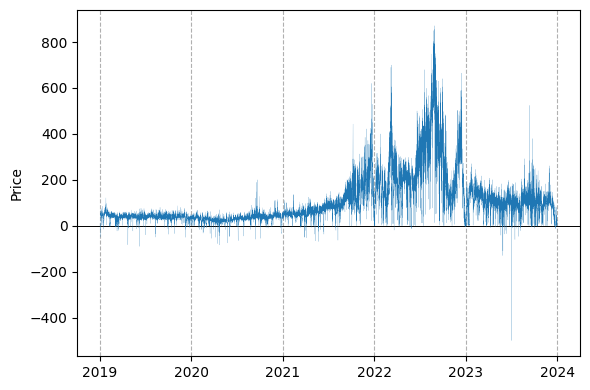

In [50]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.grid(axis='x', linestyle='--')
ax.axhline(0, color='black', linewidth=0.7)
ax.plot(
    df_train_val.index,
    df_train_val['price'],
    linewidth=0.1
)
ax.set_ylabel('Price')

fig.tight_layout()
plt.show()

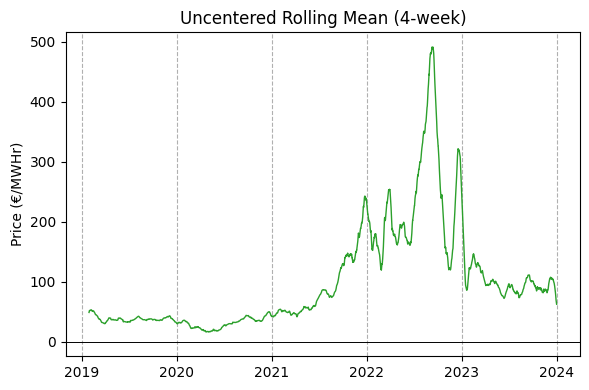

In [51]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.grid(axis='x', linestyle='--')
ax.axhline(0, color='black', linewidth=0.7)
ax.plot(
    df_train_val.index,
    df_train_val['price'].rolling(window=24*7*4).mean(),
    linewidth=1,
    c='tab:green'
)
ax.set_ylabel('Price (€/MWHr)')
ax.set_title('Uncentered Rolling Mean (4-week)')

fig.tight_layout()
plt.show()

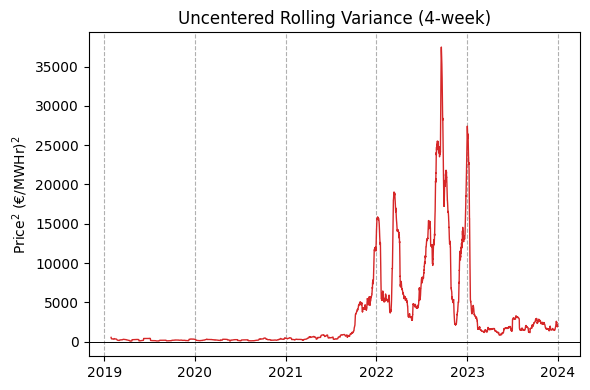

In [52]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.grid(axis='x', linestyle='--')
ax.axhline(0, color='black', linewidth=0.7)
ax.plot(
    df_train_val.index,
    df_train_val['price'].rolling(window=24*7*4).var(),
    linewidth=1,
    c='tab:red'
)
ax.set_ylabel(r'$\text{Price}^2$ $(\text{€/MWHr})^2$')
ax.set_title('Uncentered Rolling Variance (4-week)')

fig.tight_layout()
plt.show()

In [57]:
iforest = IsolationForest(max_features=df_train_imf.shape[1], random_state=0)
train_anomalies = iforest.fit_predict(df_train_imf)
val_anomalies = iforest.predict(df_val_imf)

In [58]:
rfc = RandomForestClassifier()
rfc.fit(X=df_train, y=train_anomalies)
train_anomalies_pred = rfc.predict(df_train)
val_anomalies_pred = rfc.predict(df_val)

In [78]:
df_train_val['anomaly'] = np.concat([train_anomalies, val_anomalies])
df_train_val['pred_anomaly'] = np.concat([train_anomalies_pred, val_anomalies_pred])

In [ ]:
conditions = [
    (df_train_val['anomaly'] == -1) & (df_train_val['pred_anomaly'] == -1),
    (df_train_val['anomaly'] == 1)  & (df_train_val['pred_anomaly'] == -1),
    (df_train_val['anomaly'] == 1)  & (df_train_val['pred_anomaly'] == 1),
    (df_train_val['anomaly'] == -1) & (df_train_val['pred_anomaly'] == 1),
]

choices = ['TP', 'FP', 'TN', 'FN']

df_train_val['c'] = np.select(conditions, choices, default=None)

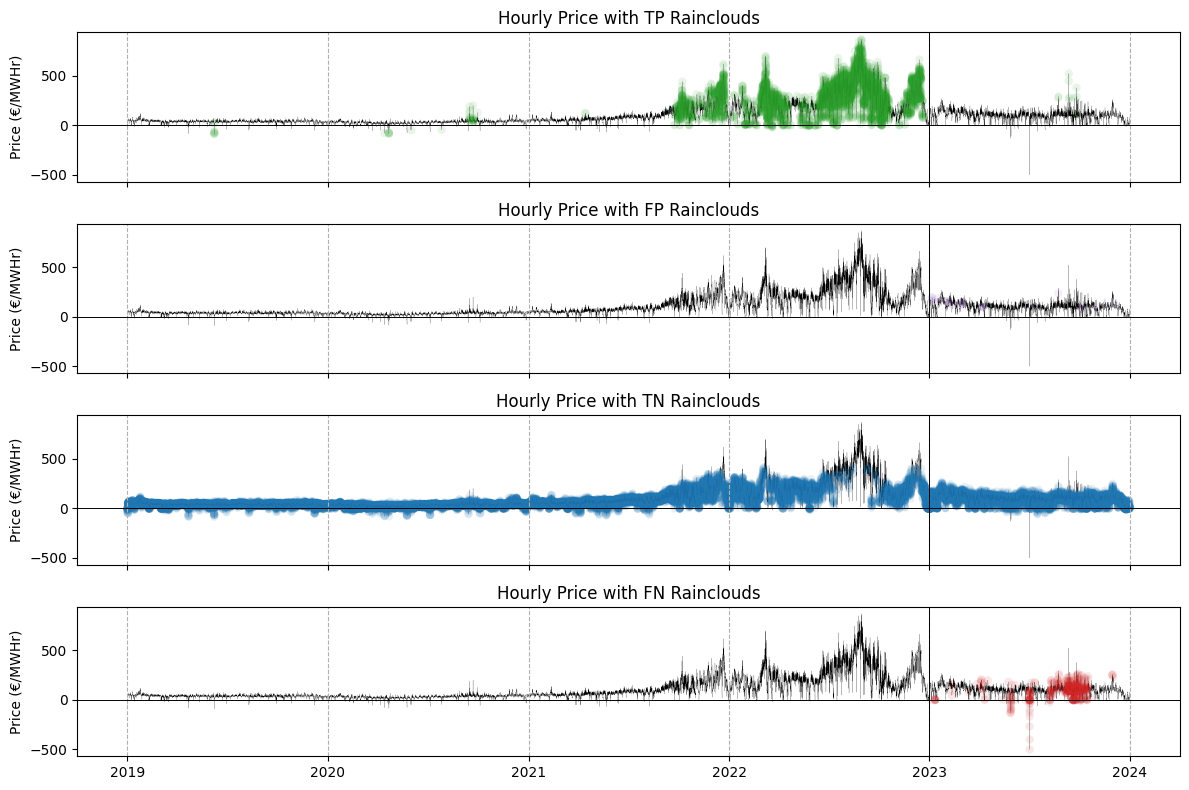

In [94]:
fig, axes = plt.subplots(4, sharex=True, figsize=(12, 8))

for ax, cat, color in zip(axes, choices, ['tab:green', 'tab:purple', 'tab:blue', 'tab:red']):
    ax.grid(axis='x', linestyle='--')
    ax.axhline(0, color='black', linewidth=0.7)
    ax.axvline(pd.to_datetime('2023-01-01 00:00:00+00:00', utc=True), color='black', linewidth=0.7)
    ax.plot(
        df_train_val.index,
        df_train_val['price'],
        color='black',
        linewidth=0.1,
        zorder=0
    )

    ax.scatter(
        df_train_val[df_train_val['c'] == cat].index,
        df_train_val[df_train_val['c'] == cat]['price'],
        color=color,
        alpha=0.1,
        zorder=1,
        label=cat,
        edgecolors='none',
        linewidths=0
    )

    ax.set_ylabel('Price (€/MWHr)')
    ax.set_title(f'Hourly Price with {cat} Rainclouds')

fig.tight_layout()
plt.show()

In [101]:
pd.qcut(df_train_val['price'].rolling(window=24*7*4).var(), q=10)

datetime
2019-01-01 00:00:00+00:00                     NaN
2019-01-01 01:00:00+00:00                     NaN
2019-01-01 02:00:00+00:00                     NaN
2019-01-01 03:00:00+00:00                     NaN
2019-01-01 04:00:00+00:00                     NaN
                                     ...         
2023-12-31 19:00:00+00:00    (1494.867, 2402.726]
2023-12-31 20:00:00+00:00    (1494.867, 2402.726]
2023-12-31 21:00:00+00:00    (1494.867, 2402.726]
2023-12-31 22:00:00+00:00    (1494.867, 2402.726]
2023-12-31 23:00:00+00:00    (1494.867, 2402.726]
Name: price, Length: 43824, dtype: category
Categories (10, interval[float64, right]): [(53.357, 145.22] < (145.22, 196.181] < (196.181, 262.317] < (262.317, 340.369] ... (1494.867, 2402.726] < (2402.726, 4766.72] < (4766.72, 11699.807] < (11699.807, 37498.626]]